In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/indian-food-dataset/Cleaned_Indian_Food_Dataset.csv
/kaggle/input/recipenlg/dataset/full_dataset.csv


**<h1>RecipeNLG Dataset</h1>**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
file_path = '/kaggle/input/recipenlg/dataset/full_dataset.csv'
df = pd.read_csv(file_path)


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2231142 entries, 0 to 2231141
Data columns (total 7 columns):
 #   Column       Dtype 
---  ------       ----- 
 0   Unnamed: 0   int64 
 1   title        object
 2   ingredients  object
 3   directions   object
 4   link         object
 5   source       object
 6   NER          object
dtypes: int64(1), object(6)
memory usage: 119.2+ MB


In [5]:
df.head()

,Unnamed: 0,title,ingredients,directions,link,source,NER
0,0,No-Bake Nut Cookies,"[""1 c. firmly packed brown sugar"", ""1/2 c. eva...","[""In a heavy 2-quart saucepan, mix brown sugar...",www.cookbooks.com/Recipe-Details.aspx?id=44874,Gathered,"[""brown sugar"", ""milk"", ""vanilla"", ""nuts"", ""bu..."
1,1,Jewell Ball'S Chicken,"[""1 small jar chipped beef, cut up"", ""4 boned ...","[""Place chipped beef on bottom of baking dish....",www.cookbooks.com/Recipe-Details.aspx?id=699419,Gathered,"[""beef"", ""chicken breasts"", ""cream of mushroom..."
2,2,Creamy Corn,"[""2 (16 oz.) pkg. frozen corn"", ""1 (8 oz.) pkg...","[""In a slow cooker, combine all ingredients. C...",www.cookbooks.com/Recipe-Details.aspx?id=10570,Gathered,"[""frozen corn"", ""cream cheese"", ""butter"", ""gar..."
3,3,Chicken Funny,"[""1 large whole chicken"", ""2 (10 1/2 oz.) cans...","[""Boil and debone chicken."", ""Put bite size pi...",www.cookbooks.com/Recipe-Details.aspx?id=897570,Gathered,"[""chicken"", ""chicken gravy"", ""cream of mushroo..."
4,4,Reeses Cups(Candy),"[""1 c. peanut butter"", ""3/4 c. graham cracker ...","[""Combine first four ingredients and press in ...",www.cookbooks.com/Recipe-Details.aspx?id=659239,Gathered,"[""peanut butter"", ""graham cracker crumbs"", ""bu..."


In [6]:
# Check for missing values
print(df.isnull().sum())

Unnamed: 0     0
title          1
ingredients    0
directions     0
link           0
source         0
NER            0
dtype: int64


In [7]:
print(f"Number of duplicate rows: {df.duplicated().sum()}")

Number of duplicate rows: 0


In [8]:
print(f"Unique titles: {df['title'].nunique()}")
print(f"Unique sources: {df['source'].nunique()}")

Unique titles: 1312870
Unique sources: 2


In [9]:
df.iloc[0]['ingredients']

'["1 c. firmly packed brown sugar", "1/2 c. evaporated milk", "1/2 tsp. vanilla", "1/2 c. broken nuts (pecans)", "2 Tbsp. butter or margarine", "3 1/2 c. bite size shredded rice biscuits"]'

In [10]:
import ast

# Convert stringified lists to actual lists
df['ingredients'] = df['ingredients'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

# Count the number of ingredients in each recipe
df['num_ingredients'] = df['ingredients'].apply(len)

print(df[['title', 'num_ingredients']].head())


                   title  num_ingredients
0    No-Bake Nut Cookies                6
1  Jewell Ball'S Chicken                4
2            Creamy Corn                6
3          Chicken Funny                5
4   Reeses Cups(Candy)                  5


In [11]:
df.iloc[0]['ingredients']

['1 c. firmly packed brown sugar',
 '1/2 c. evaporated milk',
 '1/2 tsp. vanilla',
 '1/2 c. broken nuts (pecans)',
 '2 Tbsp. butter or margarine',
 '3 1/2 c. bite size shredded rice biscuits']

In [10]:
print(df['ingredients'].head())
print(df[['title', 'num_ingredients']].head())

0    [1 c. firmly packed brown sugar, 1/2 c. evapor...
1    [1 small jar chipped beef, cut up, 4 boned chi...
2    [2 (16 oz.) pkg. frozen corn, 1 (8 oz.) pkg. c...
3    [1 large whole chicken, 2 (10 1/2 oz.) cans ch...
4    [1 c. peanut butter, 3/4 c. graham cracker cru...
Name: ingredients, dtype: object
                   title  num_ingredients
0    No-Bake Nut Cookies                6
1  Jewell Ball'S Chicken                4
2            Creamy Corn                6
3          Chicken Funny                5
4   Reeses Cups(Candy)                  5


In [11]:
import ast

# Convert stringified lists in 'directions' to actual Python lists
df['directions'] = df['directions'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

# Check the conversion
print(df['directions'].head())


0    [In a heavy 2-quart saucepan, mix brown sugar,...
1    [Place chipped beef on bottom of baking dish.,...
2    [In a slow cooker, combine all ingredients. Co...
3    [Boil and debone chicken., Put bite size piece...
4    [Combine first four ingredients and press in 1...
Name: directions, dtype: object


In [12]:
print(type(df['directions'][0]))  # Should output <class 'list'>
print(df['directions'][0])       # Should display the actual list

<class 'list'>
['In a heavy 2-quart saucepan, mix brown sugar, nuts, evaporated milk and butter or margarine.', 'Stir over medium heat until mixture bubbles all over top.', 'Boil and stir 5 minutes more. Take off heat.', 'Stir in vanilla and cereal; mix well.', 'Using 2 teaspoons, drop and shape into 30 clusters on wax paper.', 'Let stand until firm, about 30 minutes.']


In [13]:
df['num_directions'] = df['directions'].apply(len)

In [14]:
import ast

# Convert stringified lists in 'directions' to actual Python lists
df['NER'] = df['NER'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

# Check the conversion
print(df['NER'].head())


0    [brown sugar, milk, vanilla, nuts, butter, bit...
1    [beef, chicken breasts, cream of mushroom soup...
2    [frozen corn, cream cheese, butter, garlic pow...
3    [chicken, chicken gravy, cream of mushroom sou...
4    [peanut butter, graham cracker crumbs, butter,...
Name: NER, dtype: object


In [15]:
print(type(df['NER'][0]))  # Should output <class 'list'>
print(df['NER'][0])       # Should display the actual list

<class 'list'>
['brown sugar', 'milk', 'vanilla', 'nuts', 'butter', 'bite size shredded rice biscuits']


In [16]:
df.head()

,Unnamed: 0,title,ingredients,directions,link,source,NER,num_ingredients,num_directions
0,0,No-Bake Nut Cookies,"[1 c. firmly packed brown sugar, 1/2 c. evapor...","[In a heavy 2-quart saucepan, mix brown sugar,...",www.cookbooks.com/Recipe-Details.aspx?id=44874,Gathered,"[brown sugar, milk, vanilla, nuts, butter, bit...",6,6
1,1,Jewell Ball'S Chicken,"[1 small jar chipped beef, cut up, 4 boned chi...","[Place chipped beef on bottom of baking dish.,...",www.cookbooks.com/Recipe-Details.aspx?id=699419,Gathered,"[beef, chicken breasts, cream of mushroom soup...",4,3
2,2,Creamy Corn,"[2 (16 oz.) pkg. frozen corn, 1 (8 oz.) pkg. c...","[In a slow cooker, combine all ingredients. Co...",www.cookbooks.com/Recipe-Details.aspx?id=10570,Gathered,"[frozen corn, cream cheese, butter, garlic pow...",6,1
3,3,Chicken Funny,"[1 large whole chicken, 2 (10 1/2 oz.) cans ch...","[Boil and debone chicken., Put bite size piece...",www.cookbooks.com/Recipe-Details.aspx?id=897570,Gathered,"[chicken, chicken gravy, cream of mushroom sou...",5,6
4,4,Reeses Cups(Candy),"[1 c. peanut butter, 3/4 c. graham cracker cru...",[Combine first four ingredients and press in 1...,www.cookbooks.com/Recipe-Details.aspx?id=659239,Gathered,"[peanut butter, graham cracker crumbs, butter,...",5,3


In [17]:
df.iloc[0]['ingredients']

['1 c. firmly packed brown sugar',
 '1/2 c. evaporated milk',
 '1/2 tsp. vanilla',
 '1/2 c. broken nuts (pecans)',
 '2 Tbsp. butter or margarine',
 '3 1/2 c. bite size shredded rice biscuits']

In [18]:
df.iloc[0]['directions']

['In a heavy 2-quart saucepan, mix brown sugar, nuts, evaporated milk and butter or margarine.',
 'Stir over medium heat until mixture bubbles all over top.',
 'Boil and stir 5 minutes more. Take off heat.',
 'Stir in vanilla and cereal; mix well.',
 'Using 2 teaspoons, drop and shape into 30 clusters on wax paper.',
 'Let stand until firm, about 30 minutes.']

In [19]:
df.iloc[0]['NER']

['brown sugar',
 'milk',
 'vanilla',
 'nuts',
 'butter',
 'bite size shredded rice biscuits']

In [20]:
df.head()

,Unnamed: 0,title,ingredients,directions,link,source,NER,num_ingredients,num_directions
0,0,No-Bake Nut Cookies,"[1 c. firmly packed brown sugar, 1/2 c. evapor...","[In a heavy 2-quart saucepan, mix brown sugar,...",www.cookbooks.com/Recipe-Details.aspx?id=44874,Gathered,"[brown sugar, milk, vanilla, nuts, butter, bit...",6,6
1,1,Jewell Ball'S Chicken,"[1 small jar chipped beef, cut up, 4 boned chi...","[Place chipped beef on bottom of baking dish.,...",www.cookbooks.com/Recipe-Details.aspx?id=699419,Gathered,"[beef, chicken breasts, cream of mushroom soup...",4,3
2,2,Creamy Corn,"[2 (16 oz.) pkg. frozen corn, 1 (8 oz.) pkg. c...","[In a slow cooker, combine all ingredients. Co...",www.cookbooks.com/Recipe-Details.aspx?id=10570,Gathered,"[frozen corn, cream cheese, butter, garlic pow...",6,1
3,3,Chicken Funny,"[1 large whole chicken, 2 (10 1/2 oz.) cans ch...","[Boil and debone chicken., Put bite size piece...",www.cookbooks.com/Recipe-Details.aspx?id=897570,Gathered,"[chicken, chicken gravy, cream of mushroom sou...",5,6
4,4,Reeses Cups(Candy),"[1 c. peanut butter, 3/4 c. graham cracker cru...",[Combine first four ingredients and press in 1...,www.cookbooks.com/Recipe-Details.aspx?id=659239,Gathered,"[peanut butter, graham cracker crumbs, butter,...",5,3


In [21]:
max_index=df['num_ingredients'].idxmax()
max_row = df.loc[max_index]
print (max_row)

Unnamed: 0                                                    719239
title                                    Grandma'S Chicken Fricassee
ingredients        [1 lb. chopped meat, 1 egg, 1/2 c. seasoned br...
directions         [Paula and I collaborated on this recipe, and ...
link                 www.cookbooks.com/Recipe-Details.aspx?id=301776
source                                                      Gathered
NER                [chopped meat, egg, bread crumbs, ketchup, sal...
num_ingredients                                                  407
num_directions                                                     4
Name: 719239, dtype: object


/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


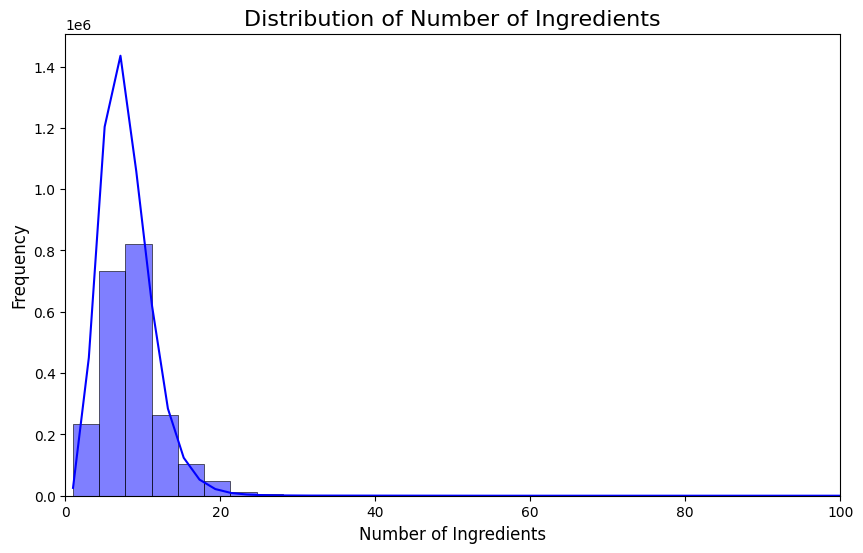

In [22]:
# Ingredients Distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['num_ingredients'], bins=120, kde=True, color='blue')
plt.xlim(0, 100)
plt.title('Distribution of Number of Ingredients', fontsize=16)
plt.xlabel('Number of Ingredients', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.show()


/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


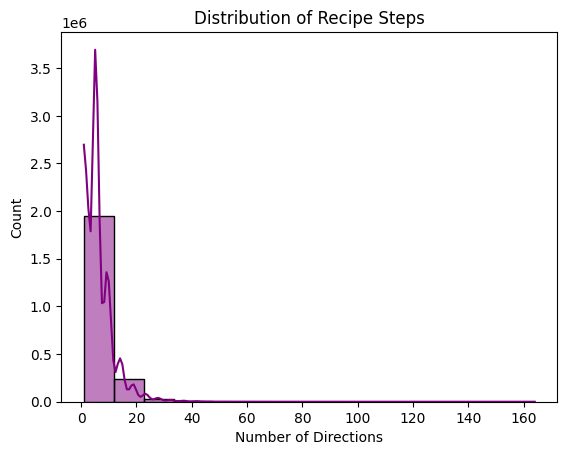

In [23]:
import seaborn as sns

# Distribution of the number of directions
sns.histplot(df['num_directions'], bins=15, kde=True, color='purple')
plt.xlabel('Number of Directions')
plt.title('Distribution of Recipe Steps')
plt.show()


/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


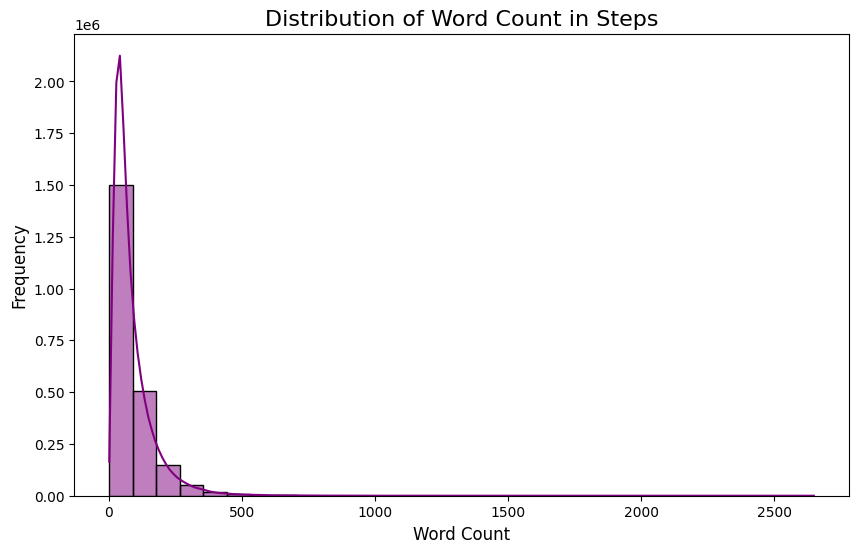

In [24]:
df['word_count_steps'] = df['directions'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(10, 6))
sns.histplot(df['word_count_steps'], bins=30, kde=True, color='purple')
plt.title('Distribution of Word Count in Steps', fontsize=16)
plt.xlabel('Word Count', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.show()


Most common entities: [('salt', 890741), ('sugar', 620027), ('butter', 493823), ('flour', 466110), ('eggs', 401276), ('onion', 372469), ('garlic', 358364), ('milk', 346769), ('water', 326092), ('vanilla', 270381)]


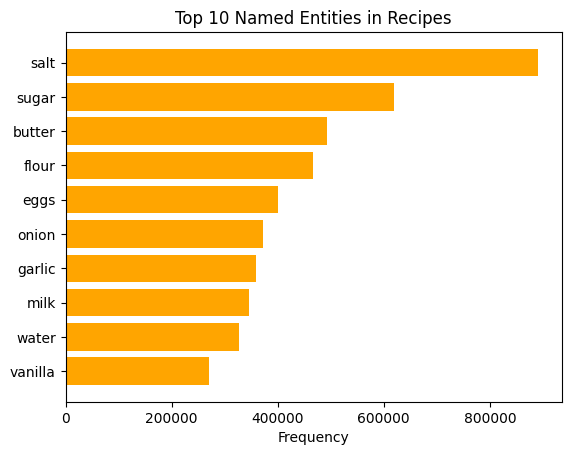

In [26]:
from collections import Counter
# Flatten the list of NER entities
all_entities = [entity for sublist in df['NER'] for entity in sublist]
entity_counts = Counter(all_entities)

# Top 10 entities
top_entities = entity_counts.most_common(10)
print("Most common entities:", top_entities)

# Plot the top entities
entities, counts = zip(*top_entities)
plt.barh(entities, counts, color='orange')
plt.xlabel('Frequency')
plt.title('Top 10 Named Entities in Recipes')
plt.gca().invert_yaxis()
plt.show()

**<h1>Indian Recipes Dataset</h1>**

In [27]:
file_path = '/kaggle/input/indian-food-dataset/Cleaned_Indian_Food_Dataset.csv'
df2 = pd.read_csv(file_path)

In [28]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5938 entries, 0 to 5937
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   TranslatedRecipeName    5938 non-null   object
 1   TranslatedIngredients   5938 non-null   object
 2   TotalTimeInMins         5938 non-null   int64 
 3   Cuisine                 5938 non-null   object
 4   TranslatedInstructions  5938 non-null   object
 5   URL                     5938 non-null   object
 6   Cleaned-Ingredients     5938 non-null   object
 7   image-url               5938 non-null   object
 8   Ingredient-count        5938 non-null   int64 
dtypes: int64(2), object(7)
memory usage: 417.6+ KB


In [29]:
df2.head()

,TranslatedRecipeName,TranslatedIngredients,TotalTimeInMins,Cuisine,TranslatedInstructions,URL,Cleaned-Ingredients,image-url,Ingredient-count
0,Masala Karela Recipe,"1 tablespoon Red Chilli powder,3 tablespoon Gr...",45,Indian,"To begin making the Masala Karela Recipe,de-se...",https://www.archanaskitchen.com/masala-karela-...,"salt,amchur (dry mango powder),karela (bitter ...",https://www.archanaskitchen.com/images/archana...,10
1,Spicy Tomato Rice (Recipe),"2 teaspoon cashew - or peanuts, 1/2 Teaspoon ...",15,South Indian Recipes,"To make tomato puliogere, first cut the tomato...",https://www.archanaskitchen.com/spicy-tomato-r...,"tomato,salt,chickpea lentils,green chilli,rice...",https://www.archanaskitchen.com/images/archana...,12
2,Ragi Semiya Upma Recipe - Ragi Millet Vermicel...,"1 Onion - sliced,1 teaspoon White Urad Dal (Sp...",50,South Indian Recipes,"To begin making the Ragi Vermicelli Recipe, fi...",https://www.archanaskitchen.com/ragi-vermicell...,"salt,rice vermicelli noodles (thin),asafoetida...",https://www.archanaskitchen.com/images/archana...,12
3,Gongura Chicken Curry Recipe - Andhra Style Go...,"1/2 teaspoon Turmeric powder (Haldi),1 tablesp...",45,Andhra,To begin making Gongura Chicken Curry Recipe f...,https://www.archanaskitchen.com/gongura-chicke...,"tomato,salt,ginger,sorrel leaves (gongura),fen...",https://www.archanaskitchen.com/images/archana...,15
4,Andhra Style Alam Pachadi Recipe - Adrak Chutn...,"oil - as per use, 1 tablespoon coriander seed...",30,Andhra,"To make Andhra Style Alam Pachadi, first heat ...",https://www.archanaskitchen.com/andhra-style-a...,"tomato,salt,ginger,red chillies,curry,asafoeti...",https://www.archanaskitchen.com/images/archana...,12


In [30]:
df2.describe()

,TotalTimeInMins,Ingredient-count
count,5938.000000,5938.000000
mean,59.846918,11.826878
std,86.416772,4.368183
min,0.000000,3.000000
25%,30.000000,9.000000
50%,40.000000,11.000000
75%,60.000000,14.000000
max,2925.000000,34.000000


In [31]:
# Check for missing values in the dataset
print(df2.isnull().sum())

TranslatedRecipeName      0
TranslatedIngredients     0
TotalTimeInMins           0
Cuisine                   0
TranslatedInstructions    0
URL                       0
Cleaned-Ingredients       0
image-url                 0
Ingredient-count          0
dtype: int64


In [32]:
# Check unique values in categorical columns
for col in ['Cuisine', 'TranslatedRecipeName']:
    print(f"Unique values in {col}: {df2[col].nunique()}")

Unique values in Cuisine: 82
Unique values in TranslatedRecipeName: 5928


In [33]:
df2.iloc[0]['TranslatedIngredients']

'1 tablespoon Red Chilli powder,3 tablespoon Gram flour (besan),2 teaspoons Cumin seeds (Jeera),1 tablespoon Coriander Powder (Dhania),2 teaspoons Turmeric powder (Haldi),Salt - to taste,1 tablespoon Amchur (Dry Mango Powder),6 Karela (Bitter Gourd/ Pavakkai) - deseeded,Sunflower Oil - as required,1 Onion - thinly sliced'

In [34]:
df2.iloc[0]['TranslatedInstructions']

'To begin making the Masala Karela Recipe,de-seed the karela and slice.\nDo not remove the skin as the skin has all the nutrients.\nAdd the karela to the pressure cooker with 3 tablespoon of water, salt and turmeric powder and pressure cook for three whistles.\nRelease the pressure immediately and open the lids.\nKeep aside.Heat oil in a heavy bottomed pan or a kadhai.\nAdd cumin seeds and let it sizzle.Once the cumin seeds have sizzled, add onions and saute them till it turns golden brown in color.Add the karela, red chilli powder, amchur powder, coriander powder and besan.\nStir to combine the masalas into the karela.Drizzle a little extra oil on the top and mix again.\nCover the pan and simmer Masala Karela stirring occasionally until everything comes together well.\nTurn off the heat.Transfer Masala Karela into a serving bowl and serve.Serve Masala Karela along with Panchmel Dal and Phulka for a weekday meal with your family.\n'

In [35]:
df2.iloc[0]['Cleaned-Ingredients']

'salt,amchur (dry mango powder),karela (bitter gourd pavakkai),red chilli powder,gram flour (besan),onion,cumin seeds (jeera),coriander powder,turmeric powder,sunflower oil'

In [36]:
# Convert the ingredients string into a list by splitting on commas
df2['TranslatedIngredients'] = df2['TranslatedIngredients'].apply(lambda x: x.split(',') if isinstance(x, str) else x)

# Check the conversion
print(df2['TranslatedIngredients'].head())


0    [1 tablespoon Red Chilli powder, 3 tablespoon ...
1    [ 2 teaspoon cashew - or peanuts,  1/2 Teaspoo...
2    [1 Onion - sliced, 1 teaspoon White Urad Dal (...
3    [1/2 teaspoon Turmeric powder (Haldi), 1 table...
4    [ oil - as per use,  1 tablespoon coriander se...
Name: TranslatedIngredients, dtype: object


In [37]:
def convert_to_list(text):
    if isinstance(text, str):
        # Replace newlines with periods, then split and clean
        steps = [step.strip() for step in text.replace('\n', '.').split('.') if step.strip()]
        return steps
    return text

# Apply the function
df2['TranslatedInstructions'] = df2['TranslatedInstructions'].apply(convert_to_list)


In [38]:
# Convert the ingredients string into a list by splitting on commas
df2['Cleaned-Ingredients'] = df2['Cleaned-Ingredients'].apply(lambda x: x.split(',') if isinstance(x, str) else x)

# Check the conversion
print(df2['Cleaned-Ingredients'].head())


0    [salt, amchur (dry mango powder), karela (bitt...
1    [tomato, salt, chickpea lentils, green chilli,...
2    [salt, rice vermicelli noodles (thin), asafoet...
3    [tomato, salt, ginger, sorrel leaves (gongura)...
4    [tomato, salt, ginger, red chillies, curry, as...
Name: Cleaned-Ingredients, dtype: object


In [39]:
df2.iloc[0]['TranslatedIngredients']

['1 tablespoon Red Chilli powder',
 '3 tablespoon Gram flour (besan)',
 '2 teaspoons Cumin seeds (Jeera)',
 '1 tablespoon Coriander Powder (Dhania)',
 '2 teaspoons Turmeric powder (Haldi)',
 'Salt - to taste',
 '1 tablespoon Amchur (Dry Mango Powder)',
 '6 Karela (Bitter Gourd/ Pavakkai) - deseeded',
 'Sunflower Oil - as required',
 '1 Onion - thinly sliced']

In [40]:
df2.iloc[0]['TranslatedInstructions']

['To begin making the Masala Karela Recipe,de-seed the karela and slice',
 'Do not remove the skin as the skin has all the nutrients',
 'Add the karela to the pressure cooker with 3 tablespoon of water, salt and turmeric powder and pressure cook for three whistles',
 'Release the pressure immediately and open the lids',
 'Keep aside',
 'Heat oil in a heavy bottomed pan or a kadhai',
 'Add cumin seeds and let it sizzle',
 'Once the cumin seeds have sizzled, add onions and saute them till it turns golden brown in color',
 'Add the karela, red chilli powder, amchur powder, coriander powder and besan',
 'Stir to combine the masalas into the karela',
 'Drizzle a little extra oil on the top and mix again',
 'Cover the pan and simmer Masala Karela stirring occasionally until everything comes together well',
 'Turn off the heat',
 'Transfer Masala Karela into a serving bowl and serve',
 'Serve Masala Karela along with Panchmel Dal and Phulka for a weekday meal with your family']

In [41]:
df2.iloc[0]['Cleaned-Ingredients']

['salt',
 'amchur (dry mango powder)',
 'karela (bitter gourd pavakkai)',
 'red chilli powder',
 'gram flour (besan)',
 'onion',
 'cumin seeds (jeera)',
 'coriander powder',
 'turmeric powder',
 'sunflower oil']

In [54]:
# Count the number of ingredients in each recipe
df2['num_directions'] = df2['TranslatedInstructions'].apply(len)

print(df2[['TranslatedRecipeName', 'num_directions']].head())


                                TranslatedRecipeName  num_directions
0                               Masala Karela Recipe              15
1                         Spicy Tomato Rice (Recipe)              11
2  Ragi Semiya Upma Recipe - Ragi Millet Vermicel...              12
3  Gongura Chicken Curry Recipe - Andhra Style Go...              17
4  Andhra Style Alam Pachadi Recipe - Adrak Chutn...              11


In [55]:
df2.head()

,TranslatedRecipeName,TranslatedIngredients,TotalTimeInMins,Cuisine,TranslatedInstructions,URL,Cleaned-Ingredients,image-url,Ingredient-count,num_directions
0,Masala Karela Recipe,"[1 tablespoon Red Chilli powder, 3 tablespoon ...",45,Indian,"[To begin making the Masala Karela Recipe,de-s...",https://www.archanaskitchen.com/masala-karela-...,"[salt, amchur (dry mango powder), karela (bitt...",https://www.archanaskitchen.com/images/archana...,10,15
1,Spicy Tomato Rice (Recipe),"[ 2 teaspoon cashew - or peanuts, 1/2 Teaspoo...",15,South Indian Recipes,"[To make tomato puliogere, first cut the tomat...",https://www.archanaskitchen.com/spicy-tomato-r...,"[tomato, salt, chickpea lentils, green chilli,...",https://www.archanaskitchen.com/images/archana...,12,11
2,Ragi Semiya Upma Recipe - Ragi Millet Vermicel...,"[1 Onion - sliced, 1 teaspoon White Urad Dal (...",50,South Indian Recipes,"[To begin making the Ragi Vermicelli Recipe, f...",https://www.archanaskitchen.com/ragi-vermicell...,"[salt, rice vermicelli noodles (thin), asafoet...",https://www.archanaskitchen.com/images/archana...,12,12
3,Gongura Chicken Curry Recipe - Andhra Style Go...,"[1/2 teaspoon Turmeric powder (Haldi), 1 table...",45,Andhra,[To begin making Gongura Chicken Curry Recipe ...,https://www.archanaskitchen.com/gongura-chicke...,"[tomato, salt, ginger, sorrel leaves (gongura)...",https://www.archanaskitchen.com/images/archana...,15,17
4,Andhra Style Alam Pachadi Recipe - Adrak Chutn...,"[ oil - as per use, 1 tablespoon coriander se...",30,Andhra,"[To make Andhra Style Alam Pachadi, first heat...",https://www.archanaskitchen.com/andhra-style-a...,"[tomato, salt, ginger, red chillies, curry, as...",https://www.archanaskitchen.com/images/archana...,12,11


In [43]:
# Group by Cuisine and calculate mean preparation time
cuisine_summary = df2.groupby('Cuisine')['TotalTimeInMins'].mean().sort_values()
print(cuisine_summary)


Cuisine
Brunch              20.000000
World Breakfast     26.000000
Shandong            30.000000
Malaysian           30.000000
Afghan              30.000000
                      ...    
South Karnataka    111.666667
Himachal           119.000000
Bihari             121.080000
Greek              128.750000
Appetizer          152.500000
Name: TotalTimeInMins, Length: 82, dtype: float64


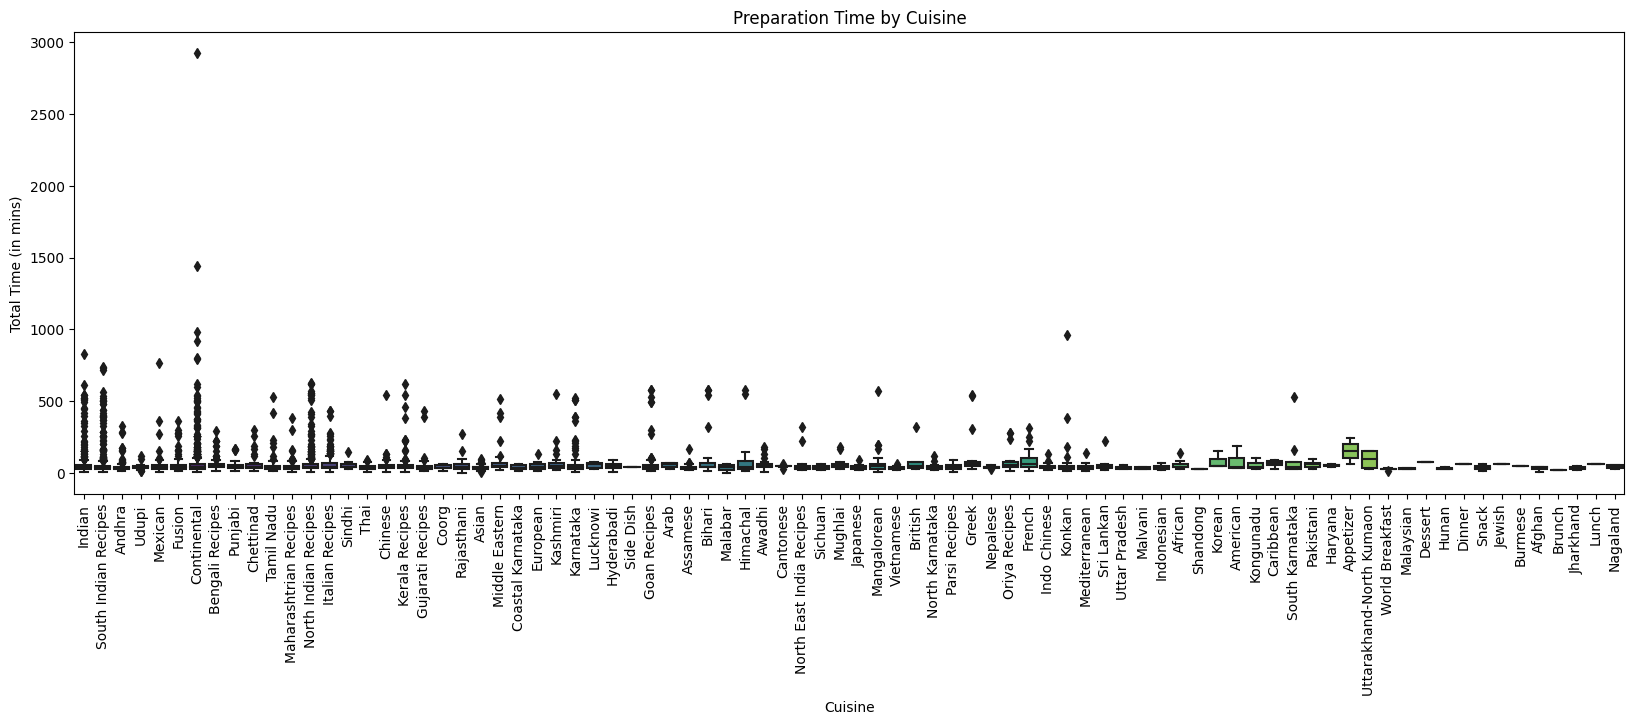

In [44]:
# Boxplot for Total Time by Cuisine
plt.figure(figsize=(20, 6))
sns.boxplot(data=df2, x='Cuisine', y='TotalTimeInMins', palette='viridis')
plt.xticks(rotation=90)
plt.title('Preparation Time by Cuisine')
plt.xlabel('Cuisine')
plt.ylabel('Total Time (in mins)')
plt.show()


/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


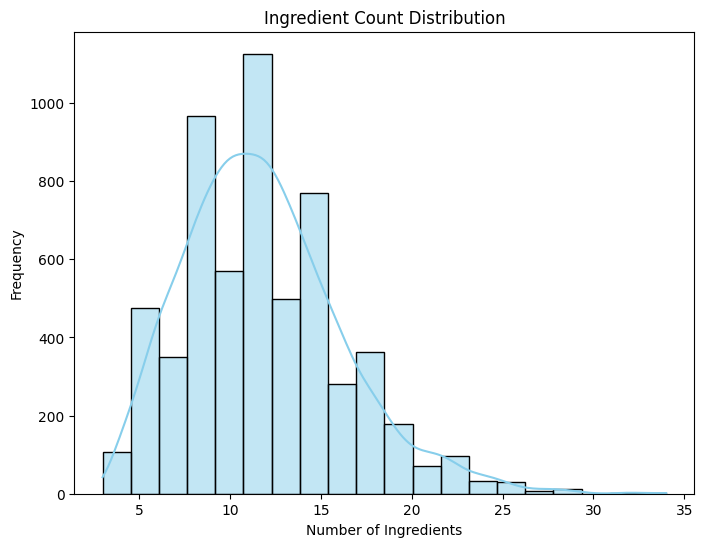

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plot distribution of ingredient counts
plt.figure(figsize=(8, 6))
sns.histplot(df2['Ingredient-count'], bins=20, kde=True, color='skyblue')
plt.title('Ingredient Count Distribution')
plt.xlabel('Number of Ingredients')
plt.ylabel('Frequency')
plt.show()


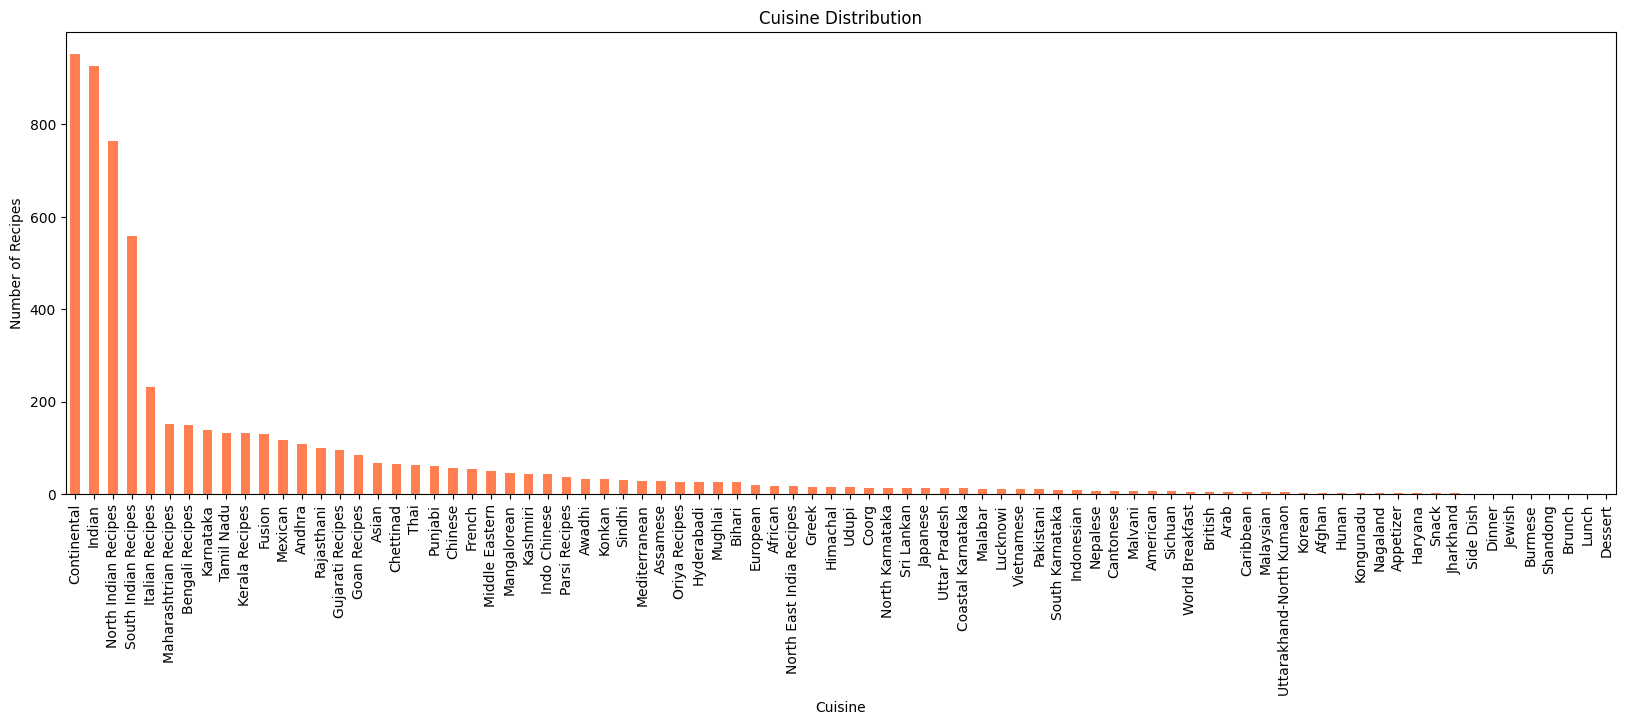

In [46]:
# Plot the distribution of cuisines
plt.figure(figsize=(20, 6))
df2['Cuisine'].value_counts().plot(kind='bar', color='coral')
plt.title('Cuisine Distribution')
plt.xlabel('Cuisine')
plt.ylabel('Number of Recipes')
plt.show()


**<h1>MERGING THE DATASETS</h1>**

In [56]:
df.head()

,Unnamed: 0,title,ingredients,directions,link,source,NER,num_ingredients,num_directions,word_count_steps
0,0,No-Bake Nut Cookies,"[1 c. firmly packed brown sugar, 1/2 c. evapor...","[In a heavy 2-quart saucepan, mix brown sugar,...",www.cookbooks.com/Recipe-Details.aspx?id=44874,Gathered,"[brown sugar, milk, vanilla, nuts, butter, bit...",6,6,60
1,1,Jewell Ball'S Chicken,"[1 small jar chipped beef, cut up, 4 boned chi...","[Place chipped beef on bottom of baking dish.,...",www.cookbooks.com/Recipe-Details.aspx?id=699419,Gathered,"[beef, chicken breasts, cream of mushroom soup...",4,3,29
2,2,Creamy Corn,"[2 (16 oz.) pkg. frozen corn, 1 (8 oz.) pkg. c...","[In a slow cooker, combine all ingredients. Co...",www.cookbooks.com/Recipe-Details.aspx?id=10570,Gathered,"[frozen corn, cream cheese, butter, garlic pow...",6,1,30
3,3,Chicken Funny,"[1 large whole chicken, 2 (10 1/2 oz.) cans ch...","[Boil and debone chicken., Put bite size piece...",www.cookbooks.com/Recipe-Details.aspx?id=897570,Gathered,"[chicken, chicken gravy, cream of mushroom sou...",5,6,63
4,4,Reeses Cups(Candy),"[1 c. peanut butter, 3/4 c. graham cracker cru...",[Combine first four ingredients and press in 1...,www.cookbooks.com/Recipe-Details.aspx?id=659239,Gathered,"[peanut butter, graham cracker crumbs, butter,...",5,3,35


In [57]:
df2.head()

,TranslatedRecipeName,TranslatedIngredients,TotalTimeInMins,Cuisine,TranslatedInstructions,URL,Cleaned-Ingredients,image-url,Ingredient-count,num_directions
0,Masala Karela Recipe,"[1 tablespoon Red Chilli powder, 3 tablespoon ...",45,Indian,"[To begin making the Masala Karela Recipe,de-s...",https://www.archanaskitchen.com/masala-karela-...,"[salt, amchur (dry mango powder), karela (bitt...",https://www.archanaskitchen.com/images/archana...,10,15
1,Spicy Tomato Rice (Recipe),"[ 2 teaspoon cashew - or peanuts, 1/2 Teaspoo...",15,South Indian Recipes,"[To make tomato puliogere, first cut the tomat...",https://www.archanaskitchen.com/spicy-tomato-r...,"[tomato, salt, chickpea lentils, green chilli,...",https://www.archanaskitchen.com/images/archana...,12,11
2,Ragi Semiya Upma Recipe - Ragi Millet Vermicel...,"[1 Onion - sliced, 1 teaspoon White Urad Dal (...",50,South Indian Recipes,"[To begin making the Ragi Vermicelli Recipe, f...",https://www.archanaskitchen.com/ragi-vermicell...,"[salt, rice vermicelli noodles (thin), asafoet...",https://www.archanaskitchen.com/images/archana...,12,12
3,Gongura Chicken Curry Recipe - Andhra Style Go...,"[1/2 teaspoon Turmeric powder (Haldi), 1 table...",45,Andhra,[To begin making Gongura Chicken Curry Recipe ...,https://www.archanaskitchen.com/gongura-chicke...,"[tomato, salt, ginger, sorrel leaves (gongura)...",https://www.archanaskitchen.com/images/archana...,15,17
4,Andhra Style Alam Pachadi Recipe - Adrak Chutn...,"[ oil - as per use, 1 tablespoon coriander se...",30,Andhra,"[To make Andhra Style Alam Pachadi, first heat...",https://www.archanaskitchen.com/andhra-style-a...,"[tomato, salt, ginger, red chillies, curry, as...",https://www.archanaskitchen.com/images/archana...,12,11


In [58]:
print(df.columns)


Index(['Unnamed: 0', 'title', 'ingredients', 'directions', 'link', 'source',
       'NER', 'num_ingredients', 'num_directions', 'word_count_steps'],
      dtype='object')


In [59]:
print(df2.columns)

Index(['TranslatedRecipeName', 'TranslatedIngredients', 'TotalTimeInMins',
       'Cuisine', 'TranslatedInstructions', 'URL', 'Cleaned-Ingredients',
       'image-url', 'Ingredient-count', 'num_directions'],
      dtype='object')


In [60]:
df = df.drop(['Unnamed: 0', 'link' , 'source' , 'word_count_steps'], axis=1)
df = df.reset_index(drop=True)

In [62]:
df2 = df2.drop(['TotalTimeInMins', 'URL' , 'image-url' ], axis=1)
df2 = df2.reset_index(drop=True)

In [65]:
df.head()

,title,ingredients,directions,NER,num_ingredients,num_directions
0,No-Bake Nut Cookies,"[1 c. firmly packed brown sugar, 1/2 c. evapor...","[In a heavy 2-quart saucepan, mix brown sugar,...","[brown sugar, milk, vanilla, nuts, butter, bit...",6,6
1,Jewell Ball'S Chicken,"[1 small jar chipped beef, cut up, 4 boned chi...","[Place chipped beef on bottom of baking dish.,...","[beef, chicken breasts, cream of mushroom soup...",4,3
2,Creamy Corn,"[2 (16 oz.) pkg. frozen corn, 1 (8 oz.) pkg. c...","[In a slow cooker, combine all ingredients. Co...","[frozen corn, cream cheese, butter, garlic pow...",6,1
3,Chicken Funny,"[1 large whole chicken, 2 (10 1/2 oz.) cans ch...","[Boil and debone chicken., Put bite size piece...","[chicken, chicken gravy, cream of mushroom sou...",5,6
4,Reeses Cups(Candy),"[1 c. peanut butter, 3/4 c. graham cracker cru...",[Combine first four ingredients and press in 1...,"[peanut butter, graham cracker crumbs, butter,...",5,3


In [66]:
df2.head()

,TranslatedRecipeName,TranslatedIngredients,Cuisine,TranslatedInstructions,Cleaned-Ingredients,Ingredient-count,num_directions
0,Masala Karela Recipe,"[1 tablespoon Red Chilli powder, 3 tablespoon ...",Indian,"[To begin making the Masala Karela Recipe,de-s...","[salt, amchur (dry mango powder), karela (bitt...",10,15
1,Spicy Tomato Rice (Recipe),"[ 2 teaspoon cashew - or peanuts, 1/2 Teaspoo...",South Indian Recipes,"[To make tomato puliogere, first cut the tomat...","[tomato, salt, chickpea lentils, green chilli,...",12,11
2,Ragi Semiya Upma Recipe - Ragi Millet Vermicel...,"[1 Onion - sliced, 1 teaspoon White Urad Dal (...",South Indian Recipes,"[To begin making the Ragi Vermicelli Recipe, f...","[salt, rice vermicelli noodles (thin), asafoet...",12,12
3,Gongura Chicken Curry Recipe - Andhra Style Go...,"[1/2 teaspoon Turmeric powder (Haldi), 1 table...",Andhra,[To begin making Gongura Chicken Curry Recipe ...,"[tomato, salt, ginger, sorrel leaves (gongura)...",15,17
4,Andhra Style Alam Pachadi Recipe - Adrak Chutn...,"[ oil - as per use, 1 tablespoon coriander se...",Andhra,"[To make Andhra Style Alam Pachadi, first heat...","[tomato, salt, ginger, red chillies, curry, as...",12,11


In [67]:
df2.rename(columns={
    "TranslatedRecipeName": "title",
    "TranslatedIngredients": "ingredients",
    "TranslatedInstructions": "directions",
    "Cleaned-Ingredients": "NER",
    "Ingredient-count": "num_ingredients"
}, inplace=True)



In [72]:
df["Cuisine"] = "General"

In [73]:
# Combine the two datasets
combined_df = pd.concat([df, df2], ignore_index=True)



In [74]:
combined_df.head()

,title,ingredients,directions,NER,num_ingredients,num_directions,Cuisine
0,No-Bake Nut Cookies,"[1 c. firmly packed brown sugar, 1/2 c. evapor...","[In a heavy 2-quart saucepan, mix brown sugar,...","[brown sugar, milk, vanilla, nuts, butter, bit...",6,6,General
1,Jewell Ball'S Chicken,"[1 small jar chipped beef, cut up, 4 boned chi...","[Place chipped beef on bottom of baking dish.,...","[beef, chicken breasts, cream of mushroom soup...",4,3,General
2,Creamy Corn,"[2 (16 oz.) pkg. frozen corn, 1 (8 oz.) pkg. c...","[In a slow cooker, combine all ingredients. Co...","[frozen corn, cream cheese, butter, garlic pow...",6,1,General
3,Chicken Funny,"[1 large whole chicken, 2 (10 1/2 oz.) cans ch...","[Boil and debone chicken., Put bite size piece...","[chicken, chicken gravy, cream of mushroom sou...",5,6,General
4,Reeses Cups(Candy),"[1 c. peanut butter, 3/4 c. graham cracker cru...",[Combine first four ingredients and press in 1...,"[peanut butter, graham cracker crumbs, butter,...",5,3,General


In [75]:
# Save the combined DataFrame as a CSV file
combined_df.to_csv('/kaggle/working/combined_recipes.csv', index=False)
